In [1]:
from datacube import Datacube
# Area of interest
from importlib.resources import files
import geopandas as gpd
from odc.geo.geom import Geometry
import requests
import io

In [2]:
dc = Datacube()

In [3]:
# View product description
products_df = dc.list_products()
products_df[products_df["name"].str.contains('esa_worldcereal')]

,name,description,license,default_crs,default_resolution
name,,,,,
esa_worldcereal_activecropland,esa_worldcereal_activecropland,ESA WorldCereal 10m 2021 v1.0.0 active croplan...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_maize_active,esa_worldcereal_maize_active,ESA WorldCereal 10m 2021 v1.0.0 active croplan...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_maize_irrigation,esa_worldcereal_maize_irrigation,ESA WorldCereal 10m 2021 v1.0.0 irrigation map...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_maize_main,esa_worldcereal_maize_main,ESA WorldCereal 10m 2021 v1.0.0 maize crop map...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_temporarycrops,esa_worldcereal_temporarycrops,ESA WorldCereal 10m 2021 v1.0.0 temporary crop...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_wintercereals,esa_worldcereal_wintercereals,ESA WorldCereal 10m 2021 v1.0.0 wintercereals ...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"
esa_worldcereal_wintercereals_irrigation,esa_worldcereal_wintercereals_irrigation,ESA WorldCereal 10m 2021 v1.0.0 irrigation map...,CC-BY-4.0,EPSG:4326,"(-8.333333333333333e-05, 8.333333333333333e-05)"


In [4]:
# List measurements
measurements_df = dc.list_measurements()
measurements_df.query("product == 'esa_worldcereal_activecropland'")

,,name,dtype,units,nodata,add_offset,scale_factor,flags_definition
product,measurement,,,,,,,
esa_worldcereal_activecropland,classification,classification,uint8,1,255,0.0,1.0,"{'data': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."


In [5]:
places_fp = "https://raw.githubusercontent.com/vikineema/deafrica_water_quality/main/src/water_quality/data/places.parquet"

response = requests.get(places_fp)
response.raise_for_status()

places_gdf = gpd.read_parquet(io.BytesIO(response.content))
place_name_list = places_gdf["name"].to_list()

place_name = "SA_smalldam1"
place = places_gdf[places_gdf["name"].isin([place_name])]
aoi_geom = Geometry(geom=place.iloc[0].geometry, crs=place.crs)

In [6]:
aoi_geom.explore()

In [7]:
ds = dc.load(
    product="esa_worldcereal_activecropland",
    geopolygon=aoi_geom,
    measurements=["classification"],
    output_crs="EPSG:6933",
    resolution=(-10,10)
)
ds

<xarray.Dataset> Size: 3kB
Dimensions:         (time: 1, y: 39, x: 49)
Coordinates:
  * time            (time) datetime64[ns] 8B 2021-08-29T11:59:59.500000
  * y               (y) float64 312B -4.072e+06 -4.072e+06 ... -4.073e+06
  * x               (x) float64 392B 1.882e+06 1.882e+06 ... 1.882e+06 1.882e+06
    spatial_ref     int32 4B 6933
Data variables:
    classification  (time, y, x) uint8 2kB 254 254 254 254 ... 254 254 254 254
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [8]:
dss =  dc.find_datasets(product="esa_worldcereal_activecropland")
dss

[Dataset <id=5c29e7d8-20c2-5332-82e8-7765332a8d6c product=esa_worldcereal_activecropland location=s3://deafrica-input-datasets/esa_worldcereal/activecropland/tc-wintercereals/10162/2021/10162_tc-wintercereals_activecropland_2021-04-28_2021-11-13.stac-item.json>,
 Dataset <id=b22e1c9c-6e97-5c10-82b7-fcf6f3536a36 product=esa_worldcereal_activecropland location=s3://deafrica-input-datasets/esa_worldcereal/activecropland/tc-wintercereals/30112/2021/30112_tc-wintercereals_activecropland_2021-05-19_2021-12-09.stac-item.json>,
 Dataset <id=75daf107-bfd3-5041-8147-570eec4c9e0e product=esa_worldcereal_activecropland location=s3://deafrica-input-datasets/esa_worldcereal/activecropland/tc-wintercereals/32115/2021/32115_tc-wintercereals_activecropland_2020-09-09_2021-04-23.stac-item.json>,
 Dataset <id=6f01f6ba-6a0f-51bf-adac-7edfb33430da product=esa_worldcereal_activecropland location=s3://deafrica-input-datasets/esa_worldcereal/activecropland/tc-wintercereals/9028/2021/9028_tc-wintercereals_acti

In [13]:
[i.time.begin - i.time.end for i in dss]

[datetime.timedelta(days=-200, seconds=1),
 datetime.timedelta(days=-205, seconds=1),
 datetime.timedelta(days=-227, seconds=1),
 datetime.timedelta(days=-244, seconds=1),
 datetime.timedelta(days=-213, seconds=1),
 datetime.timedelta(days=-234, seconds=1),
 datetime.timedelta(days=-226, seconds=1),
 datetime.timedelta(days=-266, seconds=1),
 datetime.timedelta(days=-228, seconds=1),
 datetime.timedelta(days=-205, seconds=1),
 datetime.timedelta(days=-253, seconds=1),
 datetime.timedelta(days=-247, seconds=1),
 datetime.timedelta(days=-217, seconds=1),
 datetime.timedelta(days=-227, seconds=1),
 datetime.timedelta(days=-221, seconds=1),
 datetime.timedelta(days=-174, seconds=1),
 datetime.timedelta(days=-198, seconds=1),
 datetime.timedelta(days=-209, seconds=1),
 datetime.timedelta(days=-238, seconds=1)]

In [8]:
da = ds["classification"].squeeze()
da

<xarray.DataArray 'classification' (y: 39, x: 49)> Size: 2kB
array([[254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254],
       ...,
       [254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254],
       [254, 254, 254, ..., 254, 254, 254]], shape=(39, 49), dtype=uint8)
Coordinates:
  * y            (y) float64 312B -4.072e+06 -4.072e+06 ... -4.073e+06
  * x            (x) float64 392B 1.882e+06 1.882e+06 ... 1.882e+06 1.882e+06
    time         datetime64[ns] 8B 2021-08-29T11:59:59.500000
    spatial_ref  int32 4B 6933
Attributes:
    units:             1
    nodata:            255
    add_offset:        0.0
    scale_factor:      1.0
    flags_definition:  {'data': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'values': ...
    crs:               EPSG:6933
    grid_mapping:      spatial_ref

In [9]:
from datacube.utils import masking

In [10]:
flags = masking.describe_variable_flags(da)
flags

,bits,values,description
data,"[0, 1, 2, 3, 4, 5, 6, 7]","{'0': 'inactive cropland', '100': 'active crop...",Land Use/Land Cover class


In [11]:
import numpy as np
mask = masking.make_mask(da, data='active cropland')

In [1]:
from datacube_ows.ogc_utils import rolling_window_ndays

In [2]:
help(rolling_window_ndays)

Help on function rolling_window_ndays in module datacube_ows.ogc_utils:

rolling_window_ndays(available_dates: Sequence[datetime.datetime], layer_cfg: 'datacube_ows.ows_configuration.OWSNamedLayer', ndays: int = 6) -> Tuple[datetime.datetime, datetime.datetime]
    # Example mosaic date function



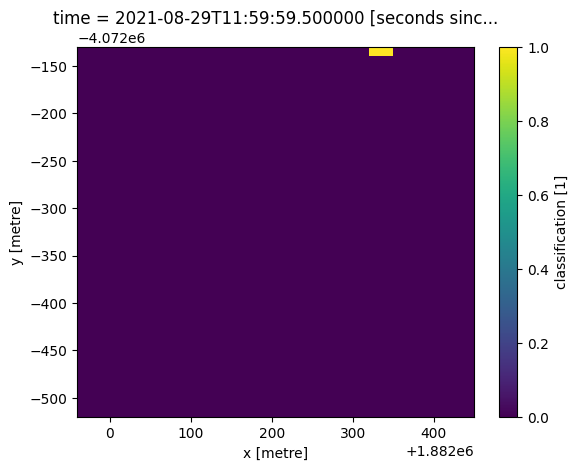

In [12]:
mask.plot.imshow();

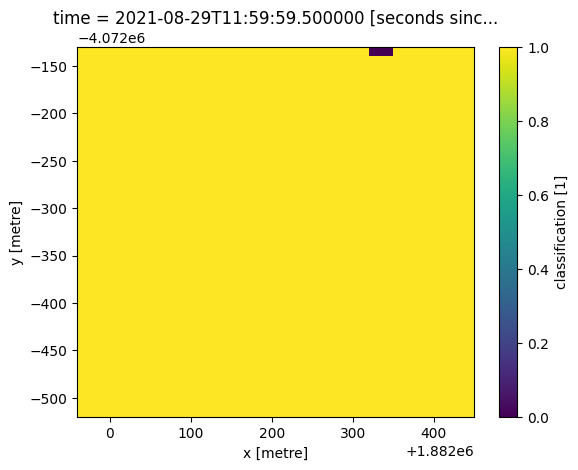

In [13]:
mask = masking.make_mask(da, data='no crop')
mask.plot.imshow();

In [19]:
import sys
sys.path.append("/home/jovyan/services/")
from ows_refactored.agriculture.ows_esa_worldcereal import style_activecropland

In [20]:
style_activecropland

{'name': 'style_activecropland',
 'title': 'Active cropland',
 'needed_bands': ['classification'],
 'index_function': {'function': 'datacube_ows.band_utils.single_band',
  'mapped_bands': True,
  'kwargs': {'band': 'classification'}},
 'value_map': {'classification': [{'title': 'Inactive cropland',
    'abstract': '',
    'values': [0],
    'color': '#f50707'},
   {'title': 'Active cropland',
    'abstract': '',
    'values': [100],
    'color': '#004f01'}]}}

In [24]:
from datacube_ows.styles.api import generate_ows_legend_style_cfg, plot_image_with_style_cfg

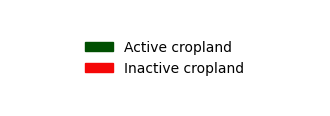

In [22]:
image = generate_ows_legend_style_cfg(style_activecropland)

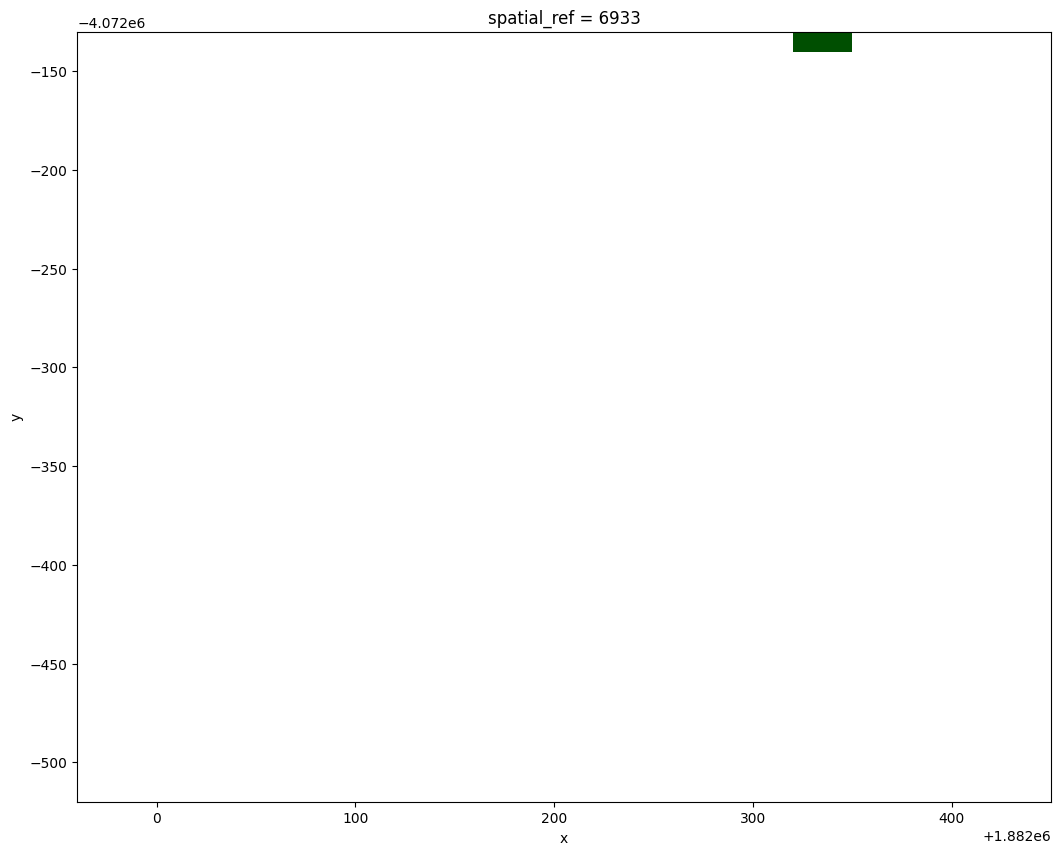

In [25]:
plot_image_with_style_cfg(style_activecropland, ds)